# Warrior Play-Style Axes — deck-conditioned behavioral signatures

Read a player's personal play-style from their card-play logs along **4 interpretable
axes**, *separating what the player chooses from what the deck forces*, using only real
human ranked games — and proving the read stays stable when the same player switches decks.

> *Prior work reads the cards; this reads the player — and proves the read isn't just the deck talking.*

## The 4 axes

| Axis | +1 pole | −1 pole |
|---|---|---|
| **aggro ↔ control** | short games, cheap curve, reach/burn | long games, removal/heal/taunt/draw, late finishers |
| **tempo ↔ value** | board development, early coin | draw-for-value, big bombs, saved coin |
| **risk** *(experimental)* | RNG/Discover, heavy early commitment | low-RNG, steady on-curve |
| **greedy ↔ efficient** | high avg cost, bombs, wasted mana | tight mana use, cheap on-curve |

## The method (the novel core)

For each game *g* (player *p*, archetype *d*) and feature *f*:

```
z(g,f)   = ( x(g,f) − center[d,f] ) / scale[d,f]   ← deck baseline from ALL games of deck d
Z(p,f)   = mean of z(g,f) over player p's games
R(p)     = Σ_f  sign_f · weight_f · Z(p,f)          ← one axis
axis(p)  = tanh( standardize_over_players( R(p) ) ) ← spread to (−1, 1)
```

`center[d,f]` / `scale[d,f]` are **what the deck forces** (robust median / MAD over the
population). The leftover `z` is **what the player chose** — the deck-conditioned residual
is the entire contribution. No board state required.

## Data sources & one important data finding

- **`warrior_dataframes.pkl`** → cleaned `games` frame (25,302 ranked Warrior games, 161 players)
  with per-game numeric stats (`rounds`, `mana_eff`, `coin_turn`, `first_turn`, `hero_deck`…).
- **Card identity was *not* in the pickles.** The pickle `cards` frame kept only `mana`, not
  card names — so the 8 tag-based (`†`) features cannot be built from it. They are recovered
  here by **re-parsing the monthly dumps** (`dataset/hearthstonemap/20*.json`), whose
  `card_history` carries `player` / `turn` / `card.{id,name,mana}`. `card.id` joins directly
  to `cards_meta.json`. 100% of pickle games are found in the dumps; 98.5% carry a played-card
  history.

## Honesty notes (carry these into the paper)
- **risk** is the weakest axis — only two thin proxies (`rng_share`, `early_commit`), no board
  state to judge true "play-around" risk. If it doesn't validate, dropping to 3 axes is a
  *finding*, not a failure.
- `avg_cost` is shared by **aggro** (−) and **greed** (+); `topend_share` by **tempo** (−) and
  **greed** (+). These *will* correlate — check the 4×4 matrix in Stage 4 and re-weight/merge if
  needed. `mana_eff` lives in **greed only**, on purpose, so tempo and greed don't collapse.
- Card tags are **text/mechanic regex heuristics**, not ground truth.
- Side note: the raw logs actually *do* contain board state (`my_health`, `my_board`, …) — so the
  old MCTS "objective play quality" idea isn't permanently dead; it's **Future Work**, not a gap.

## Stage 0 — Config & imports

In [1]:
import json, glob, os, re, pickle, time
import numpy as np
import pandas as pd

ROOT      = r"d:\test"
DUMP_GLOB = os.path.join(ROOT, "dataset", "hearthstonemap", "20*.json")
META_PATH = os.path.join(ROOT, "hearthstonemap-master", "hearthstonemap-master",
                         "data-processing", "cards_meta.json")
GAMES_PKL = os.path.join(ROOT, "warrior_dataframes.pkl")
CACHE_PKL = os.path.join(ROOT, "warrior_me_cards.pkl")   # parsed me-card cache

COIN_ID          = "GAME_005"   # The Coin — excluded from cost/share features
MIN_GAMES_PLAYER = 15           # min games to score a player
DECK_MIN_GAMES   = 30           # archetype baseline guard
DECK_MIN_PLAYERS = 5

## Stage 0 — Load the cleaned Warrior games frame

In [2]:
d = pickle.load(open(GAMES_PKL, "rb"))
games = d["games"].copy()
games["game_id"] = games["game_id"].astype(int)
gids = set(games["game_id"])
print(f"{len(games)} warrior games | {games['user_hash'].nunique()} players")
games["hero_deck"].value_counts(dropna=False)

25302 warrior games | 161 players


hero_deck
Pirate     13594
Unknown     3890
Dragon      3530
Taunt       1654
Control     1400
C'Thun       740
Tempo        298
Worgen       196
Name: count, dtype: int64

## Stage 1a — Recover card identity from the monthly dumps

The cleaned `cards` frame dropped card names, so we re-parse the raw monthly dumps to recover
the list of cards **the player ("me") actually played** per game, keyed by `game_id`. Result is
cached to `warrior_me_cards.pkl` (~12 s parse; instant on reload).

In [3]:
def parse_me_cards(gids, dump_glob):
    plays = {}
    for f in sorted(glob.glob(dump_glob)):
        j = json.load(open(f, encoding="utf-8"))
        for g in j["games"]:
            gid = int(g["id"])
            if gid not in gids:
                continue
            ch = g.get("card_history") or []
            me = [{"turn": c["turn"], "id": c["card"].get("id"),
                   "name": c["card"].get("name"), "mana": c["card"].get("mana")}
                  for c in ch if c.get("player") == "me" and c.get("card")]
            if me:
                plays[gid] = me
        del j
    return plays

t0 = time.time()
if os.path.exists(CACHE_PKL):
    plays = pickle.load(open(CACHE_PKL, "rb"))
    print(f"loaded cache: {len(plays)} games")
else:
    plays = parse_me_cards(gids, DUMP_GLOB)
    pickle.dump(plays, open(CACHE_PKL, "wb"))
    print(f"parsed {len(plays)} games in {time.time()-t0:.1f}s -> cache")
print(f"coverage: {len(plays)/len(gids):.1%} of warrior games have a played-card history")

loaded cache: 24925 games
coverage: 98.5% of warrior games have a played-card history


## Stage 1b — Card tag table from `cards_meta.json`

Each played `card.id` is tagged using `type`, `mechanics`, `text`, and `cost`. These are
**heuristics** (regex over card text + mechanic flags), not ground truth — verify a few by hand
if a tag drives a surprising result.

| Tag | Rule |
|---|---|
| `minion` / `spell` / `weapon` | `type` |
| `deal_dmg` (burn/reach) | text matches `deal $N damage` |
| `removal` | "destroy … minion" or "damage to … minion" |
| `draw` | text contains "draw" |
| `heal` | "restore … health" / "heal" |
| `taunt` | TAUNT mechanic or text |
| `charge` | CHARGE mechanic or text |
| `rng` | DISCOVER mechanic, or "random" / "discover" in text |

In [4]:
meta = json.load(open(META_PATH, encoding="utf-8"))

def build_tags(meta):
    T = {}
    for c in meta:
        cid = c.get("id")
        if not cid:
            continue
        typ  = c.get("type")
        text = (c.get("text") or "").lower()
        mech = set(c.get("mechanics") or [])
        deal_dmg = bool(re.search(r"deal\s+\$?\d+\s+damage", text))
        removal  = (("destroy" in text and "minion" in text)
                    or bool(re.search(r"damage to (a|all|an|the)?\s*\w*\s*minion", text))
                    or "destroy all minions" in text)
        T[cid] = dict(minion=(typ == "MINION"), weapon=(typ == "WEAPON"),
                      spell=(typ == "SPELL"), cost=c.get("cost"), deal_dmg=deal_dmg,
                      removal=removal, draw=("draw" in text),
                      heal=(("restore" in text and "health" in text) or "heal" in text),
                      taunt=("TAUNT" in mech or "taunt" in text),
                      charge=("CHARGE" in mech or "charge" in text),
                      rng=("DISCOVER" in mech or "random" in text or "discover" in text))
    return T

T = build_tags(meta)
DEFAULT = dict(minion=False, weapon=False, spell=False, cost=None, deal_dmg=False,
               removal=False, draw=False, heal=False, taunt=False, charge=False, rng=False)

played_ids = {c["id"] for cards in plays.values() for c in cards}
unknown = [i for i in played_ids if i not in T]
print(f"{len(T)} cards tagged | {len(played_ids)} distinct played | unknown to meta: {len(unknown)}")

3474 cards tagged | 910 distinct played | unknown to meta: 0


## Stage 1c — Per-game features

Per game, over the player's played non-Coin cards. `†` = needs the tag table above.

| Feature | Meaning |
|---|---|
| `avg_cost` | mean mana of played cards |
| `minion_share` † | share that are minions (board development) |
| `draw_share` † | share that draw cards (value) |
| `topend_share` † | share with cost ≥ 7 (bombs) |
| `cheap_share` † | share with cost ≤ 2 (low curve) |
| `aggro_share` † | share with Charge or direct damage (reach/face) |
| `control_share` † | share that remove / heal / Taunt / draw (stabilizing) |
| `rng_share` † | share that are random / Discover (variance) |
| `early_commit` † | minion mana on turns ≤ 4 ÷ total mana played |

Joined with numeric per-game stats already in the games frame: `rounds`, `mana_eff`,
`coin_turn`, `first_turn`.

In [5]:
def game_features(cards):
    noncoin = [c for c in cards if c["id"] != COIN_ID]
    n = len(noncoin)
    if n == 0:
        return None
    def tg(c): return T.get(c["id"], DEFAULT)
    costs = [c["mana"] for c in noncoin if c["mana"] is not None]
    total_mana = sum(costs) or 1.0
    def share(pred): return sum(bool(pred(c)) for c in noncoin) / n
    early_minion_mana = sum((c["mana"] or 0) for c in noncoin
                            if tg(c)["minion"] and c["turn"] <= 4)
    return dict(
        n_cards_me   = n,
        avg_cost     = float(np.mean(costs)) if costs else np.nan,
        minion_share = share(lambda c: tg(c)["minion"]),
        draw_share   = share(lambda c: tg(c)["draw"]),
        topend_share = share(lambda c: (c["mana"] or 0) >= 7),
        cheap_share  = share(lambda c: (c["mana"] or 0) <= 2),
        aggro_share  = share(lambda c: tg(c)["charge"] or tg(c)["deal_dmg"]),
        control_share= share(lambda c: tg(c)["removal"] or tg(c)["heal"]
                             or tg(c)["taunt"] or tg(c)["draw"]),
        rng_share    = share(lambda c: tg(c)["rng"]),
        early_commit = early_minion_mana / total_mana,
    )

rows = []
for gid, cards in plays.items():
    f = game_features(cards)
    if f:
        f["game_id"] = gid
        rows.append(f)
tagdf = pd.DataFrame(rows)

NUM = ["rounds", "mana_eff", "coin_turn", "first_turn"]
feat = games[["game_id", "user_hash", "hero_deck", "rank", "win"] + NUM].merge(
    tagdf, on="game_id", how="inner")

FEATURES = ["rounds", "avg_cost", "mana_eff", "coin_turn",
            "minion_share", "draw_share", "topend_share", "cheap_share",
            "aggro_share", "control_share", "rng_share", "early_commit"]
print("feature matrix:", feat.shape)
feat[["hero_deck"] + FEATURES].head()

feature matrix: (24925, 19)


,hero_deck,rounds,avg_cost,mana_eff,coin_turn,minion_share,draw_share,topend_share,cheap_share,aggro_share,control_share,rng_share,early_commit
0,Dragon,14.0,3.055556,0.639535,1.0,0.722222,0.055556,0.000000,0.388889,0.444444,0.555556,0.055556,0.127273
1,Dragon,9.0,3.000000,0.847826,1.0,0.769231,0.000000,0.076923,0.461538,0.615385,0.384615,0.153846,0.153846
2,Dragon,9.0,2.769231,0.800000,NaN,0.769231,0.153846,0.000000,0.461538,0.384615,0.538462,0.000000,0.138889
3,Dragon,7.0,2.300000,0.821429,NaN,0.600000,0.000000,0.000000,0.700000,0.300000,0.400000,0.100000,0.173913
4,Dragon,8.0,2.909091,0.888889,NaN,0.727273,0.181818,0.090909,0.545455,0.454545,0.454545,0.090909,0.187500


## Stage 2 — Deck-conditioned baseline *(the novel core)*

For each archetype `d` and feature `f` we compute a **robust center/scale** (median / MAD,
×1.4826) over the whole population of that deck — *what the deck forces*. Each game is then
expressed as a deck-adjusted residual `z(g,f)`.

**Guards:** only archetypes with ≥ 30 games **and** ≥ 5 players get their own baseline; thin
archetypes and `Unknown` fall back to a pooled all-Warrior baseline (`POOL`). MAD of 0 falls
back to std, then to 1.

In [6]:
def robust_center_scale(s):
    s = s.dropna()
    if len(s) == 0:
        return 0.0, 1.0
    med = float(np.median(s))
    mad = float(np.median(np.abs(s - med))) * 1.4826
    if mad < 1e-9:
        sd = float(s.std()); mad = sd if sd > 1e-9 else 1.0
    return med, mad

deck_stats = games.groupby("hero_deck")["user_hash"].agg(["count", "nunique"])
qualified = set(deck_stats[(deck_stats["count"] >= DECK_MIN_GAMES) &
                           (deck_stats["nunique"] >= DECK_MIN_PLAYERS)].index)
qualified.discard("Unknown")
print("qualified archetypes:", sorted(qualified))

baselines = {}
for f in FEATURES:
    baselines[("POOL", f)] = robust_center_scale(feat[f])
    for dk in qualified:
        baselines[(dk, f)] = robust_center_scale(feat.loc[feat["hero_deck"] == dk, f])

def deck_key(dk): return dk if dk in qualified else "POOL"

Z = feat[["game_id", "user_hash", "hero_deck"]].copy()
for f in FEATURES:
    cs  = feat["hero_deck"].map(lambda dk: baselines[(deck_key(dk), f)])
    cen = cs.map(lambda t: t[0]).astype(float)
    scl = cs.map(lambda t: t[1]).astype(float)
    Z[f] = (feat[f] - cen) / scl
print("deck-adjusted residuals Z:", Z.shape)

qualified archetypes: ["C'Thun", 'Control', 'Dragon', 'Pirate', 'Taunt', 'Tempo', 'Worgen']
deck-adjusted residuals Z: (24925, 15)


## Stage 3 — Axis scoring

`(feature, sign, weight)` per axis (v1 starting weights — tune after seeing Stage 4):

- **aggro_control:** rounds −.30, avg_cost −.20, aggro_share +.20, control_share −.20, cheap_share +.10
- **tempo_value:** draw_share −.35, minion_share +.25, topend_share −.20, coin_turn −.20
- **risk:** rng_share +.60, early_commit +.40
- **greedy_eff:** mana_eff −.40, avg_cost +.30, topend_share +.30

In [7]:
AXES = {
    "aggro_control": [("rounds", -1, .30), ("avg_cost", -1, .20),
                      ("aggro_share", +1, .20), ("control_share", -1, .20),
                      ("cheap_share", +1, .10)],
    "tempo_value":   [("draw_share", -1, .35), ("minion_share", +1, .25),
                      ("topend_share", -1, .20), ("coin_turn", -1, .20)],
    "risk":          [("rng_share", +1, .60), ("early_commit", +1, .40)],
    "greedy_eff":    [("mana_eff", -1, .40), ("avg_cost", +1, .30),
                      ("topend_share", +1, .30)],
}
AX = list(AXES.keys())

def standardize(s):
    sd = s.std()
    return (s - s.mean()) / (sd if sd > 1e-9 else 1.0)

gb = Z.groupby("user_hash")
ngames  = gb.size()
players = ngames[ngames >= MIN_GAMES_PLAYER].index
Zp = gb[FEATURES].mean().loc[players]            # Z(p,f)

axis_scores = pd.DataFrame(index=players)
for axis, terms in AXES.items():
    R = sum(sign * w * Zp[f] for f, sign, w in terms)
    axis_scores[axis] = np.tanh(standardize(R))
axis_scores["n_games"] = ngames.loc[players]

axis_scores.to_csv(os.path.join(ROOT, "warrior_playstyle_axes.csv"))
print(f"scored {len(axis_scores)} players (>= {MIN_GAMES_PLAYER} games) -> warrior_playstyle_axes.csv")
axis_scores.round(3).head(12)

scored 126 players (>= 15 games) -> warrior_playstyle_axes.csv


,aggro_control,tempo_value,risk,greedy_eff,n_games
user_hash,,,,,
01DE27F723DBA6AA3F3D9B085A292626,-0.923,-0.491,-0.225,0.978,455
02BE56C56050E98A011C31340F4376F0,-0.569,-0.999,-0.979,-0.313,29
03019D3B5094E121EBCEEB6F21F0FBE5,-0.033,-0.114,-0.078,0.278,499
03C9A80213B75DD46F4C1DF6EA966B42,-1.000,-0.999,0.951,0.967,21
0595B1E1C48983DE1176D93870B0FD6F,0.858,0.521,-0.165,-0.579,251
0675131D304DFB550A83C54A92568BBE,0.598,-0.823,-0.060,-0.086,65
08559CE836A3FD14B06DAAE60F74C1B8,0.508,0.292,0.386,-0.652,192
0A89B858BCA8B415A945FF6F713FD15D,-0.159,0.029,-0.691,0.189,278
0B6D8FCDD2400CC700D587FF06CBED79,0.604,0.269,0.127,-0.382,441


## Stage 4 — Validation *(what turns it from a script into research)*

1. **Axis independence** — 4×4 correlation of the final axis values.
2. **Split-half consistency** — first vs second half of each player's games should agree.
3. **Within- vs between-player variance** — between should dominate (trait, not noise).
4. **Cross-deck stability** — same player on different decks → similar deck-adjusted read.
5. **Face validity** — extreme players should match intuition.

In [8]:
# (1) axis independence
corr = axis_scores[AX].corr()
print("4x4 axis correlation:")
display(corr.round(2))
print("Expected redundancy: avg_cost links aggro(-)/greed(+); topend_share links tempo(-)/greed(+).")

4x4 axis correlation:


,aggro_control,tempo_value,risk,greedy_eff
aggro_control,1.00,0.66,0.31,-0.78
tempo_value,0.66,1.00,0.26,-0.61
risk,0.31,0.26,1.00,-0.07
greedy_eff,-0.78,-0.61,-0.07,1.00


Expected redundancy: avg_cost links aggro(-)/greed(+); topend_share links tempo(-)/greed(+).


In [9]:
# (2) split-half consistency (interleave a player's games; compare pre-tanh R)
def score_subset(idx):
    sg = Z.loc[idx].groupby("user_hash")[FEATURES].mean()
    out = pd.DataFrame(index=sg.index)
    for axis, terms in AXES.items():
        out[axis] = standardize(sum(sign * w * sg[f] for f, sign, w in terms))
    return out

order = Z.groupby("user_hash").cumcount()
A = score_subset(Z.index[order % 2 == 0])
B = score_subset(Z.index[order % 2 == 1])
common = A.index.intersection(B.index).intersection(players)
print(f"split-half on {len(common)} players:")
for axis in AX:
    r = np.corrcoef(A.loc[common, axis], B.loc[common, axis])[0, 1]
    print(f"  {axis:14s} r = {r:+.2f}")

split-half on 126 players:
  aggro_control  r = +0.86
  tempo_value    r = +0.88
  risk           r = +0.76
  greedy_eff     r = +0.84


In [10]:
# (3) between- vs within-player variance of the game-level axis contribution
print("between/within variance ratio (higher = more trait-like):")
for axis, terms in AXES.items():
    Zc = Z.copy()
    Zc["R"] = sum(sign * w * Zc[f] for f, sign, w in terms)
    sub = Zc[Zc["user_hash"].isin(players)]
    grand = sub["R"].mean()
    pm = sub.groupby("user_hash")["R"]
    between = ((pm.mean() - grand) ** 2 * pm.size()).sum() / (len(players) - 1)
    within  = sub.groupby("user_hash")["R"].apply(
                  lambda s: ((s - s.mean()) ** 2).sum()).sum() / (len(sub) - len(players))
    print(f"  {axis:14s} {between/within:6.2f}")

between/within variance ratio (higher = more trait-like):
  aggro_control   17.25
  tempo_value     61.72
  risk            19.08
  greedy_eff      18.84


In [11]:
# (4) cross-deck stability: players spanning >=2 qualified archetypes (>=10 games each)
pc = feat[feat.user_hash.isin(players)].groupby(["user_hash", "hero_deck"]).size()
pairs = []
for uh in players:
    decks = pc.loc[uh]
    decks = decks[(decks.index.isin(qualified)) & (decks >= 10)]
    if len(decks) >= 2:
        pairs.append((uh, list(decks.index)))
print(f"{len(pairs)} players span >=2 qualified archetypes (>=10 games each)")
if pairs:
    spreads = []
    for uh, decks in pairs:
        per = pd.DataFrame([Z.loc[(Z.user_hash == uh) & (Z.hero_deck == dk), FEATURES].mean()
                            for dk in decks])
        spreads.append(per.std().mean())
    print(f"mean within-player across-deck feature std: {np.mean(spreads):.2f}")
    print("(~1.0 would mean deck conditioning did nothing; lower = stable cross-deck signature)")

64 players span >=2 qualified archetypes (>=10 games each)
mean within-player across-deck feature std: 0.37
(~1.0 would mean deck conditioning did nothing; lower = stable cross-deck signature)


In [12]:
# (5) face validity: extreme players per axis
print("face-validity extremes (player hash prefix):")
for axis in AX:
    hi, lo = axis_scores[axis].idxmax(), axis_scores[axis].idxmin()
    print(f"  {axis:14s} max={axis_scores.loc[hi,axis]:+.2f} ({hi[:8]})   "
          f"min={axis_scores.loc[lo,axis]:+.2f} ({lo[:8]})")

face-validity extremes (player hash prefix):
  aggro_control  max=+0.95 (1CF4F23E)   min=-1.00 (03C9A802)
  tempo_value    max=+0.85 (E8F1B761)   min=-1.00 (02BE56C5)
  risk           max=+1.00 (B8BE6F7F)   min=-0.98 (02BE56C5)
  greedy_eff     max=+1.00 (A291E82C)   min=-0.98 (1CF4F23E)


## Profile plots

Radar charts of the 4 axes per player (like `profile_gambler.png` / `profile_safe.png`). We plot
the most extreme player on each axis as a face-validity spot check.

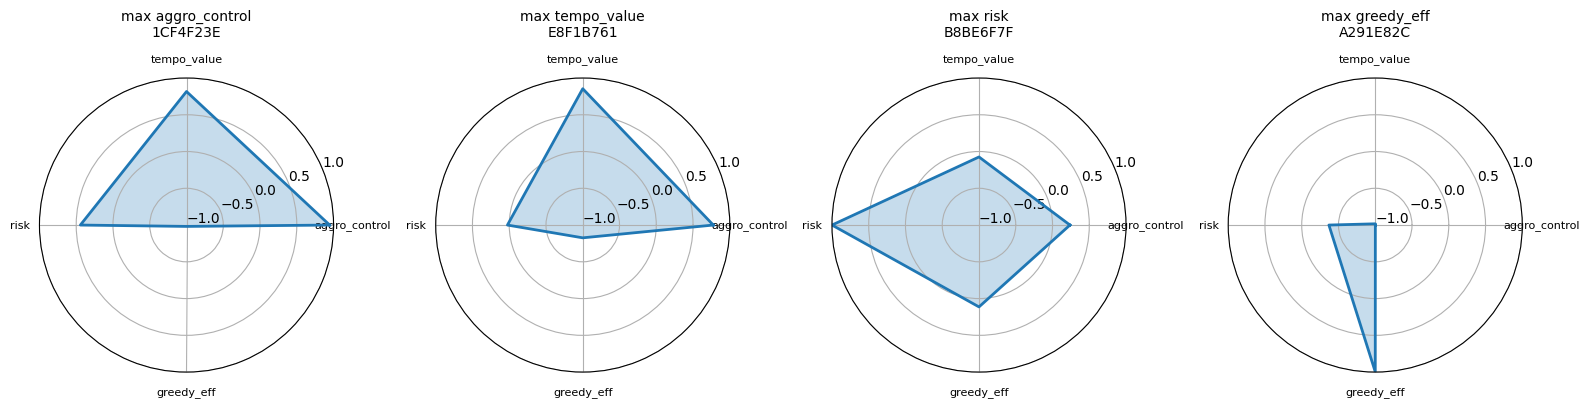

In [13]:
import matplotlib.pyplot as plt

def radar(ax, vals, labels, title):
    n = len(labels)
    ang = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    v = list(vals) + [vals[0]]; a = ang + [ang[0]]
    ax.plot(a, v, lw=2); ax.fill(a, v, alpha=.25)
    ax.set_xticks(ang); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(-1, 1); ax.set_yticks([-1, -.5, 0, .5, 1])
    ax.set_title(title, fontsize=10, pad=12)

picks = [axis_scores[a].idxmax() for a in AX]
titles = [f"max {a}\n{uh[:8]}" for a, uh in zip(AX, picks)]
fig, axs = plt.subplots(1, 4, subplot_kw=dict(polar=True), figsize=(16, 4))
for ax, uh, ttl in zip(axs, picks, titles):
    radar(ax, axis_scores.loc[uh, AX].values, AX, ttl)
plt.tight_layout(); plt.show()

## Findings & next steps

**Reliability (run output above):** split-half r ≈ 0.76–0.88 and between/within variance ≈ 17–62×
across axes → the deck-adjusted reads are stable traits, not game-to-game noise. Cross-deck
feature drift ≈ 0.37 (vs ~1.0 null) → the signature largely survives a deck switch, which is the
core claim.

**Redundancy to resolve before publishing:** `aggro_control` vs `greedy_eff` correlate strongly
(shared `avg_cost`, opposite signs) and `tempo_value` vs `greedy_eff` moderately (shared
`topend_share`). Inspect the 4×4 matrix and either re-weight or merge. `risk` is the most
independent but rests on two thin proxies — report its weakness openly; dropping to 3 axes is a
valid finding.

**Tunables:** `MIN_GAMES_PLAYER`, `DECK_MIN_GAMES/PLAYERS`, and the per-axis weights are v1
values — tune against the Stage 4 diagnostics, not a priori.

**Future work (not a gap):** the raw logs *do* contain board state (`my_health`, `my_board`,
`opponent_board`, hand sizes). The MCTS "objective play-quality" idea is therefore possible later;
it's deferred, not impossible. Other extensions: all-classes baselines, archetype inference for the
`Unknown` (~15%) games, and clustering players on the 4 axes for discrete style labels.